# Sign Language


## Runtime Setup


In [6]:
import os
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.utils import load_img, img_to_array


from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow version:", tf.__version__)
print("Available GPUs:", gpus)

if not gpus:
    print("GPU not detected. In Colab, enable GPU from Runtime -> Change runtime type -> GPU.")




TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Step 1 - Load and Inspect the Dataset


In [8]:
train_dir = "/content/drive/MyDrive/AI-ML/Sign Language Detection/Train"
test_dir = "/content/drive/MyDrive/AI-ML/Sign Language Detection/Test"

class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))],
    key=int,
)

records = []
invalid_files = []
size_counter = Counter()
channel_counter = Counter()

for class_name in class_names:
    class_dir = os.path.join(train_dir, class_name)
    for file_name in sorted(os.listdir(class_dir)):
        file_path = os.path.join(class_dir, file_name)
        if not os.path.isfile(file_path):
            continue

        try:
            with Image.open(file_path) as img:
                img.verify()
            with Image.open(file_path) as img:
                width, height = img.size
                channels = len(img.getbands())

            records.append(
                {
                    "filepath": file_path,
                    "label": class_name,
                    "width": width,
                    "height": height,
                    "channels": channels,
                }
            )
            size_counter[(width, height)] += 1
            channel_counter[channels] += 1
        except Exception as exc:
            invalid_files.append(
                {
                    "filepath": file_path,
                    "label": class_name,
                    "error_type": type(exc).__name__,
                }
            )

sign_df = pd.DataFrame(records)
invalid_df = pd.DataFrame(invalid_files)

num_classes = sign_df["label"].nunique()
total_valid_images = len(sign_df)
total_raw_files = total_valid_images + len(invalid_df)

class_distribution = (
    sign_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
class_distribution["label"] = class_distribution["label"].astype(int)
class_distribution = class_distribution.sort_values("label").reset_index(drop=True)

print(f"Total raw files found        : {total_raw_files}")
print(f"Valid readable images        : {total_valid_images}")
print(f"Corrupt/unreadable images    : {len(invalid_df)}")
print(f"Number of classes            : {num_classes}")
print(f"Channel distribution         : {dict(channel_counter)}")
print(f"Most common image sizes      : {size_counter.most_common(5)}")
print()
print("Dataset shape (valid images DataFrame):", sign_df.shape)
print()
print("Images per class:")
display(class_distribution)

if not invalid_df.empty:
    print("Sample corrupt files:")
    display(invalid_df.head(10))

Total raw files found        : 11058
Valid readable images        : 10792
Corrupt/unreadable images    : 266
Number of classes            : 38
Channel distribution         : {3: 10792}
Most common image sizes      : [((224, 224), 10792)]

Dataset shape (valid images DataFrame): (10792, 5)

Images per class:


,label,count
0,0,286
1,1,287
2,2,291
3,3,279
4,4,239
5,5,287
6,6,284
7,7,282
8,8,290
9,9,285


Sample corrupt files:


,filepath,label,error_type
0,/content/drive/MyDrive/AI-ML/Sign Language Det...,0,UnidentifiedImageError
1,/content/drive/MyDrive/AI-ML/Sign Language Det...,0,UnidentifiedImageError
2,/content/drive/MyDrive/AI-ML/Sign Language Det...,0,UnidentifiedImageError
3,/content/drive/MyDrive/AI-ML/Sign Language Det...,0,UnidentifiedImageError
4,/content/drive/MyDrive/AI-ML/Sign Language Det...,0,UnidentifiedImageError
5,/content/drive/MyDrive/AI-ML/Sign Language Det...,0,UnidentifiedImageError
6,/content/drive/MyDrive/AI-ML/Sign Language Det...,0,UnidentifiedImageError
7,/content/drive/MyDrive/AI-ML/Sign Language Det...,1,UnidentifiedImageError
8,/content/drive/MyDrive/AI-ML/Sign Language Det...,1,UnidentifiedImageError
9,/content/drive/MyDrive/AI-ML/Sign Language Det...,1,UnidentifiedImageError


In [9]:
print("Image width summary")
display(sign_df["width"].describe())

print("Image height summary")
display(sign_df["height"].describe())

Image width summary


,width
count,10792.0
mean,224.0
std,0.0
min,224.0
25%,224.0
50%,224.0
75%,224.0
max,224.0


Image height summary


,height
count,10792.0
mean,224.0
std,0.0
min,224.0
25%,224.0
50%,224.0
75%,224.0
max,224.0


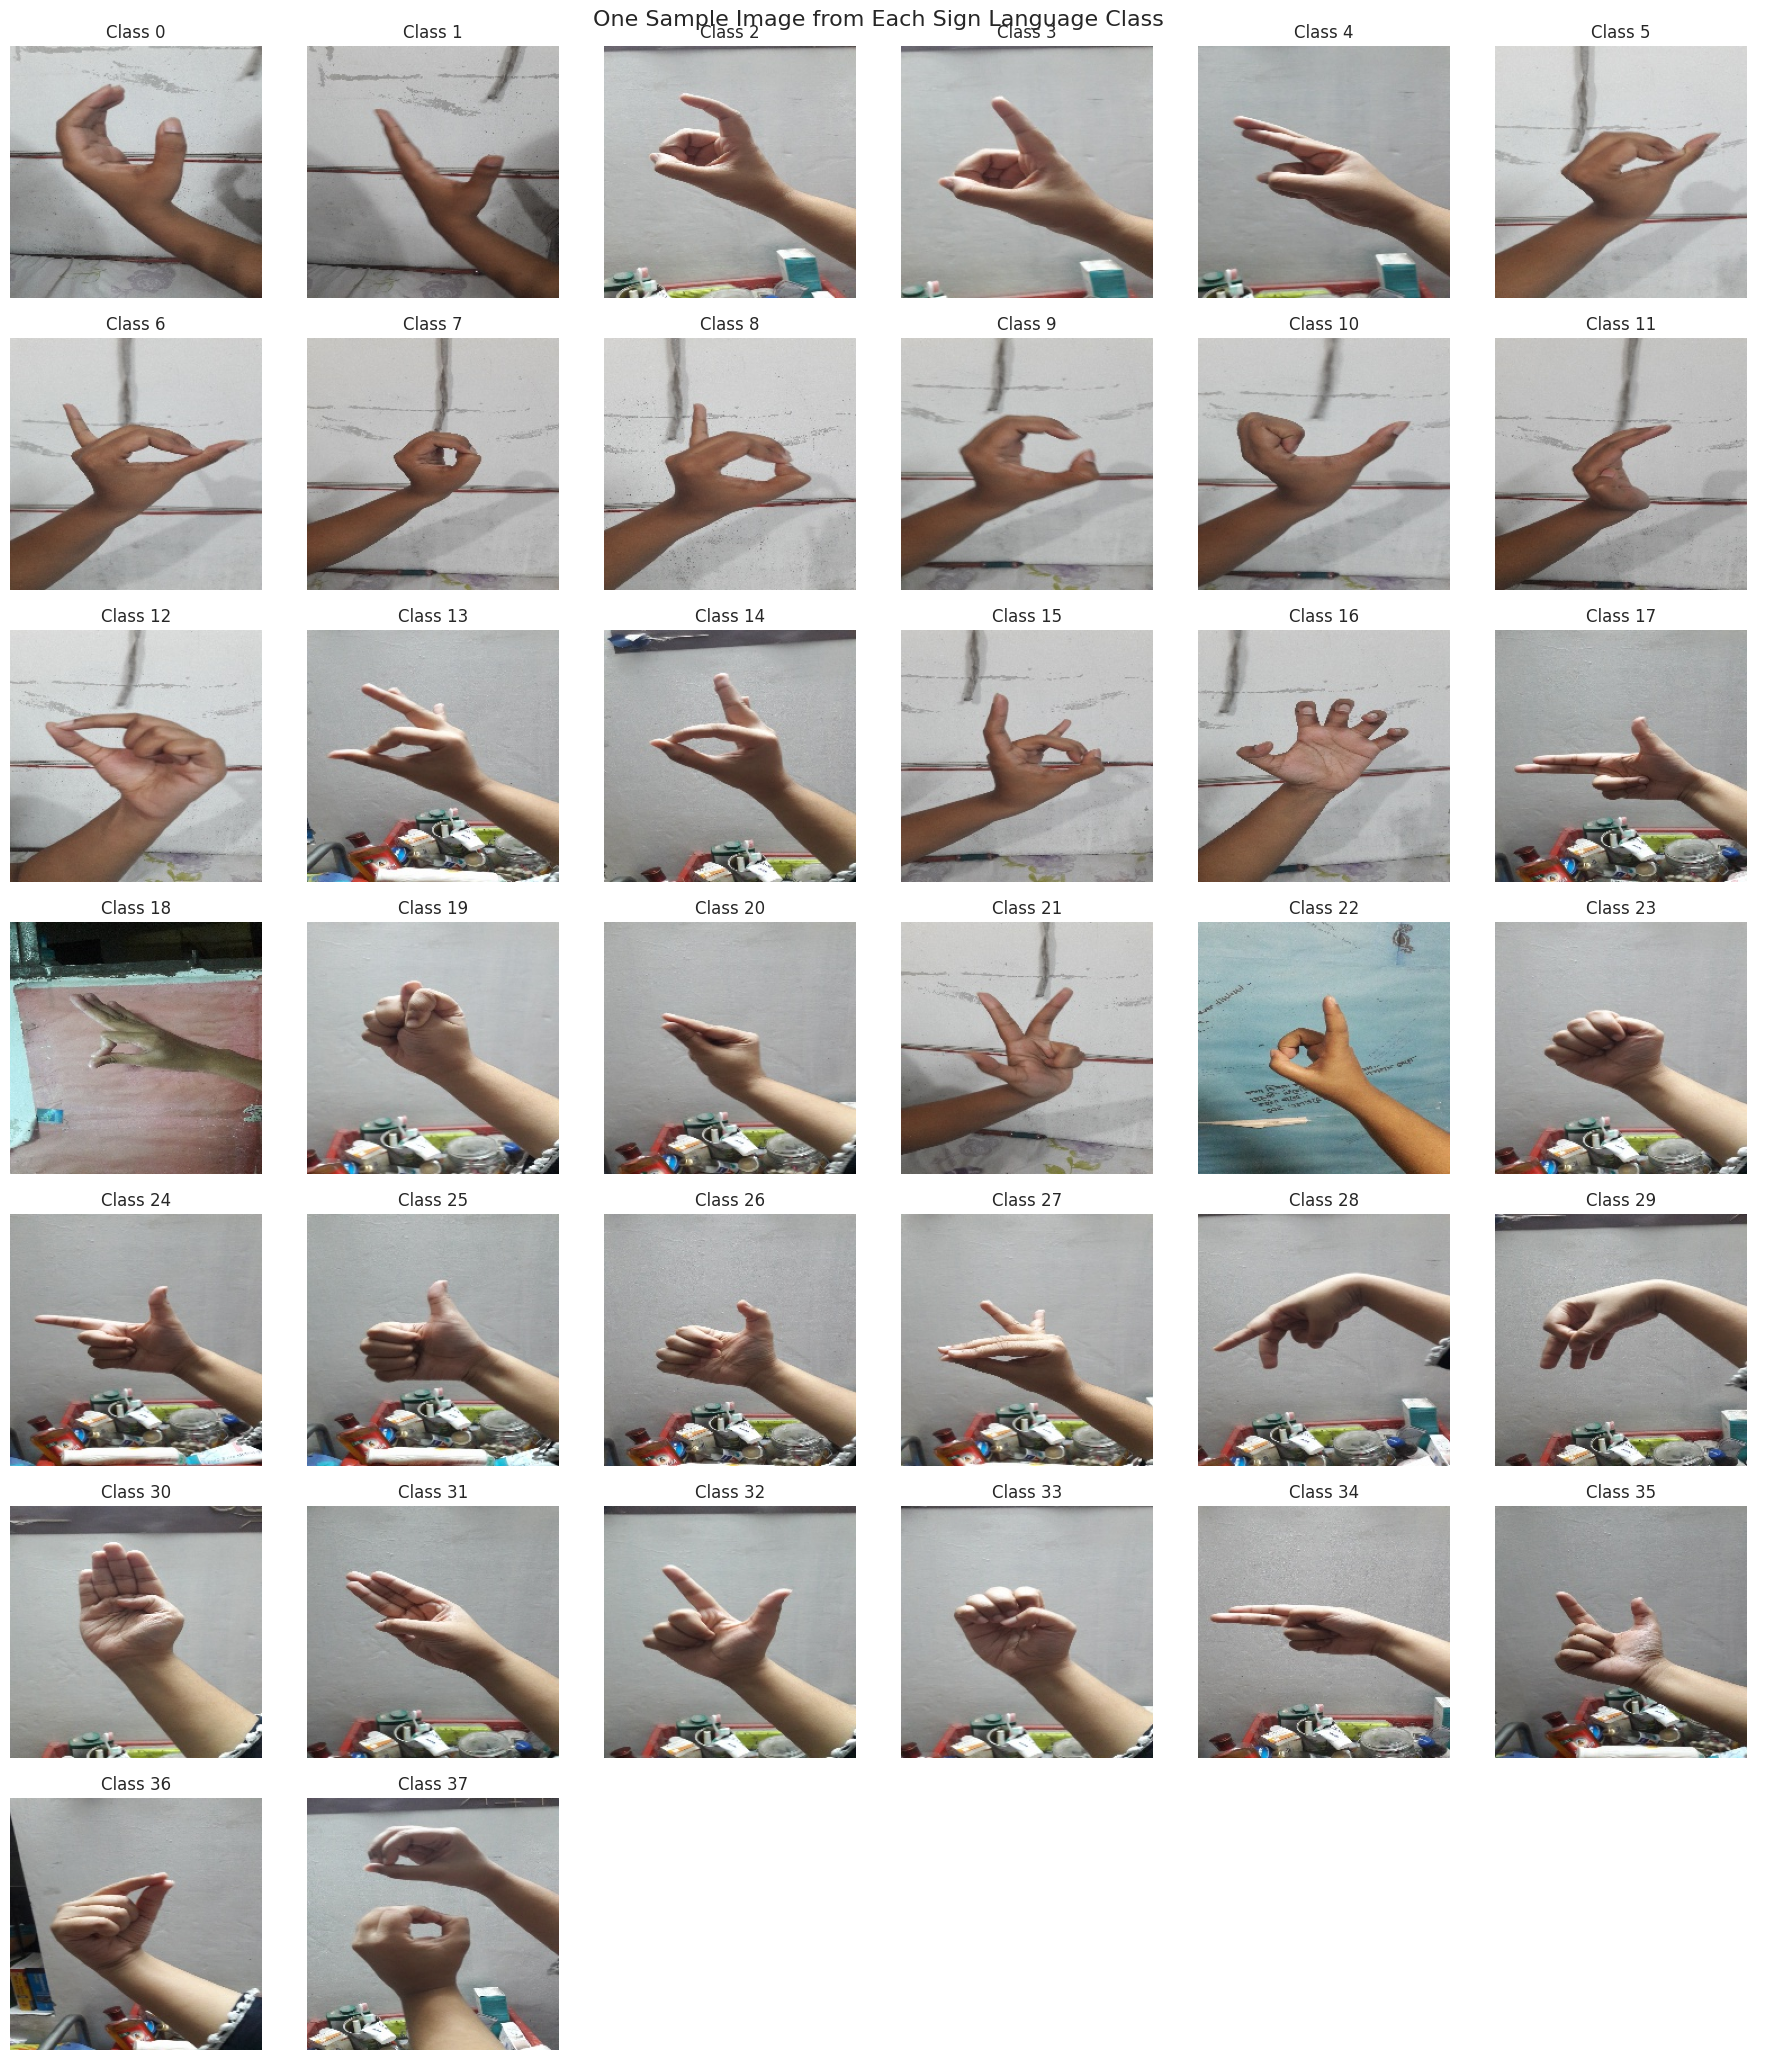

In [10]:
samples_per_class = (
    sign_df.sort_values(["label", "filepath"], key=lambda col: col.astype(str))
    .groupby("label", as_index=False)
    .head(1)
    .copy()
)
samples_per_class["label_int"] = samples_per_class["label"].astype(int)
samples_per_class = samples_per_class.sort_values("label_int")

n_classes = len(samples_per_class)
ncols = 6
nrows = int(np.ceil(n_classes / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 3 * nrows))
axes = axes.flatten()

for ax, (_, row) in zip(axes, samples_per_class.iterrows()):
    img = load_img(row["filepath"])
    ax.imshow(img)
    ax.set_title(f"Class {row['label']}")
    ax.axis("off")

for ax in axes[n_classes:]:
    ax.axis("off")

plt.suptitle("One Sample Image from Each Sign Language Class", fontsize=16)
plt.tight_layout()
plt.show()

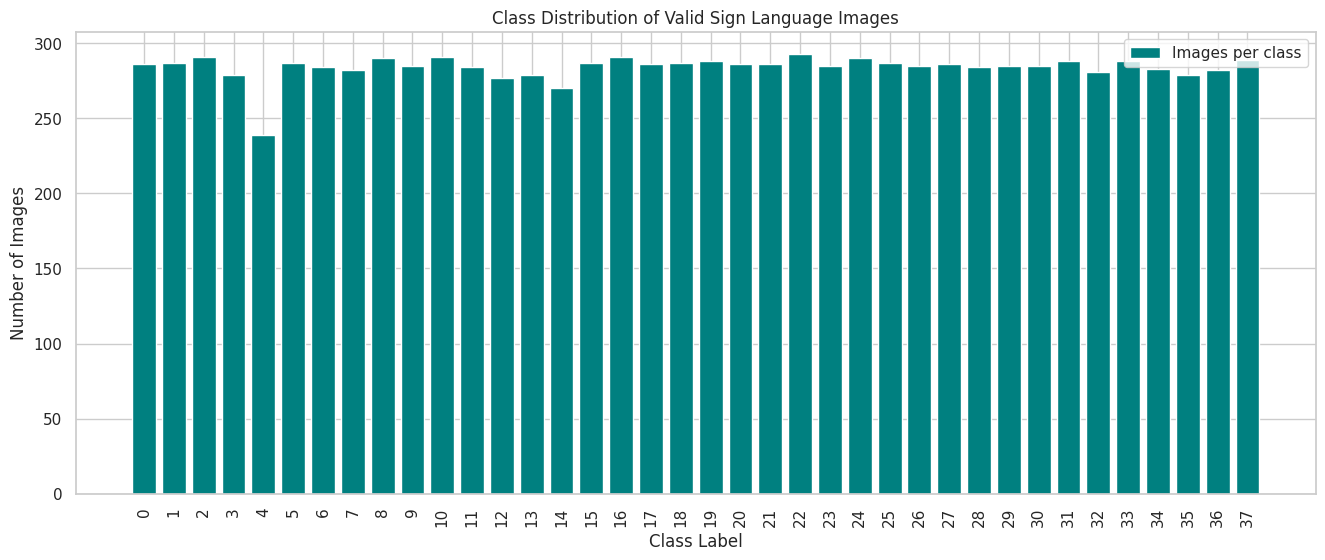

Minimum class count: 239
Maximum class count: 293
Mean class count   : 284.0


In [11]:
plt.figure(figsize=(16, 6))
plt.bar(class_distribution["label"].astype(str), class_distribution["count"], color="teal", label="Images per class")
plt.title("Class Distribution of Valid Sign Language Images")
plt.xlabel("Class Label")
plt.ylabel("Number of Images")
plt.legend()
plt.xticks(rotation=90)
plt.show()

print("Minimum class count:", class_distribution["count"].min())
print("Maximum class count:", class_distribution["count"].max())
print("Mean class count   :", round(class_distribution["count"].mean(), 2))




In [12]:
train_df, val_df = train_test_split(
    sign_df,
    test_size=0.20,
    stratify=sign_df["label"],
    random_state=SEED,
)



print("Training samples  :", len(train_df))
print("Validation samples:", len(val_df))
print("Training classes  :", train_df["label"].nunique())
print("Validation classes:", val_df["label"].nunique())

split_summary = pd.DataFrame(
    {
        "train_count": train_df["label"].value_counts().sort_index(key=lambda s: s.astype(int)),
        "val_count": val_df["label"].value_counts().sort_index(key=lambda s: s.astype(int)),
    }
).reset_index(names="label")

display(split_summary.head(10))

Training samples  : 8633
Validation samples: 2159
Training classes  : 38
Validation classes: 38


,label,train_count,val_count
0,0,229,57
1,1,230,57
2,2,233,58
3,3,223,56
4,4,191,48
5,5,230,57
6,6,227,57
7,7,226,56
8,8,232,58
9,9,228,57


In [13]:
target_size = (64, 64)
batch_size = 32

train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=(0.9, 1.1),
    fill_mode="nearest",
)

val_datagen = ImageDataGenerator(rescale=1.0 / 255)

ordered_classes = [str(label) for label in sorted(sign_df["label"].astype(int).unique())]

train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col="filepath",
    y_col="label",
    classes=ordered_classes,
    target_size=target_size,
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=True,
    seed=SEED,
)

val_generator = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    x_col="filepath",
    y_col="label",
    classes=ordered_classes,
    target_size=target_size,
    class_mode="categorical",
    batch_size=batch_size,
    shuffle=False,
)

input_shape = train_generator.image_shape
num_classes = len(train_generator.class_indices)  # fix here

print("Target size selected from data :", target_size)
print("Input shape from generator      :", input_shape)
print("Number of classes from data     :", num_classes)

Found 8633 validated image filenames belonging to 38 classes.
Found 2159 validated image filenames belonging to 38 classes.
Target size selected from data : (64, 64)
Input shape from generator      : (64, 64, 3)
Number of classes from data     : 38


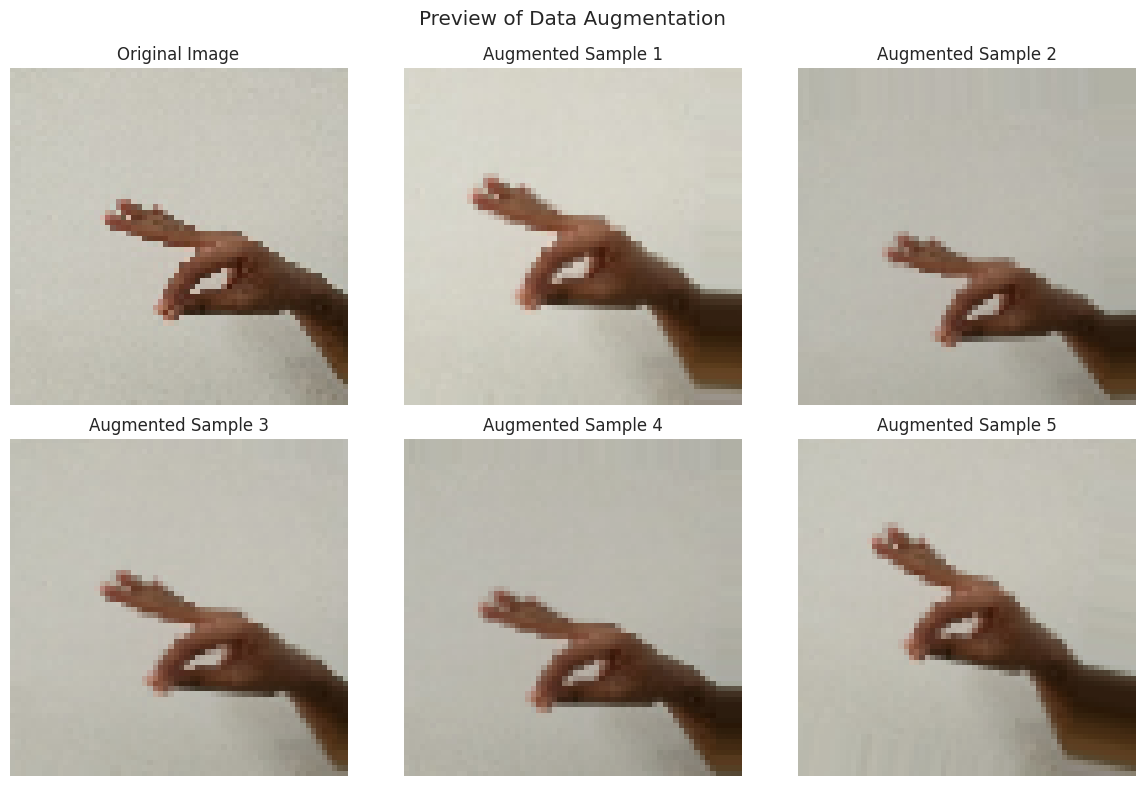

In [14]:
sample_path = train_df.sample(1, random_state=SEED)["filepath"].iloc[0]
original = load_img(sample_path, target_size=target_size)
original_array = img_to_array(original)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

axes[0].imshow(original)
axes[0].set_title("Original Image")
axes[0].axis("off")

for idx in range(1, 6):
    augmented = train_datagen.random_transform(original_array.copy())
    augmented = train_datagen.standardize(augmented)
    axes[idx].imshow(np.clip(augmented, 0, 1))
    axes[idx].set_title(f"Augmented Sample {idx}")
    axes[idx].axis("off")

plt.suptitle("Preview of Data Augmentation")
plt.tight_layout()
plt.show()

# Step 2 - Baseline CNN Model


In [15]:
from tensorflow.keras.layers import BatchNormalization, Dropout

def build_baseline_cnn(input_shape, num_classes):
    model = Sequential(
        [
            Input(shape=input_shape),

            # Block 1
            Conv2D(32, (3, 3), activation="relu", padding="same"),
            BatchNormalization(),   # ← add
            MaxPooling2D(pool_size=(2, 2)),

            # Block 2
            Conv2D(64, (3, 3), activation="relu", padding="same"),
            BatchNormalization(),   # ← add
            MaxPooling2D(pool_size=(2, 2)),

            # Block 3
            Conv2D(128, (3, 3), activation="relu", padding="same"),
            BatchNormalization(),   # ← add
            MaxPooling2D(pool_size=(2, 2)),

            GlobalAveragePooling2D(),

            Dense(256, activation="relu"),
            Dropout(0.4),          # ← add
            Dense(128, activation="relu"),
            Dropout(0.3),          # ← add
            Dense(64, activation="relu"),
            Dense(num_classes, activation="softmax"),
        ]
    )
    return model


baseline_model = build_baseline_cnn(input_shape=input_shape, num_classes=num_classes)

baseline_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

baseline_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 38)             │         2,470 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 170,790 (667.15 KB)

 Trainable params: 170,342 (665.40 KB)

 Non-trainable params: 448 (1.75 KB)

In [16]:
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def get_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]

def load_data_as_arrays(df, target_size=(64, 64)):
    X, y = [], []
    for _, row in df.iterrows():
        img = load_img(row["filepath"], target_size=target_size)
        img = img_to_array(img) / 255.0
        X.append(img)
        y.append(int(row["label"]))
    X = np.array(X)
    y = tf.keras.utils.to_categorical(y, num_classes=num_classes)
    return X, y

print("Loading training data...")
X_train, y_train = load_data_as_arrays(train_df)
print("Loading validation data...")
X_val, y_val = load_data_as_arrays(val_df)
print("X_train shape:", X_train.shape)

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.15,
    height_shift_range=0.15,
    zoom_range=0.15,
    horizontal_flip=False,
    fill_mode="nearest"
)

tf.keras.backend.clear_session()

baseline_model = build_baseline_cnn(
    input_shape=(64, 64, 3),
    num_classes=num_classes
)

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

start_time = time.perf_counter()

baseline_history = baseline_model.fit(
    datagen.flow(X_train, y_train, batch_size=32, seed=SEED),
    validation_data=(X_val, y_val),
    epochs=20,
    callbacks=get_callbacks(),
    verbose=1,
)

baseline_training_time = time.perf_counter() - start_time
print(f"Training time: {baseline_training_time:.2f} seconds")

baseline_model.save("/content/drive/MyDrive/AI-ML/baseline_model.keras")
print("Baseline model saved!")

Loading training data...
Loading validation data...
X_train shape: (8633, 64, 64, 3)
Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 28s 70ms/step - accuracy: 0.0426 - loss: 3.6269 - val_accuracy: 0.0283 - val_loss: 3.6894 - learning_rate: 0.0010
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.0848 - loss: 3.3712 - val_accuracy: 0.0398 - val_loss: 3.5551 - learning_rate: 0.0010
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.1932 - loss: 2.7460 - val_accuracy: 0.0723 - val_loss: 3.4488 - learning_rate: 0.0010
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 13s 47ms/step - accuracy: 0.3602 - loss: 2.0468 - val_accuracy: 0.3969 - val_loss: 1.9226 - learning_rate: 0.0010
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 12s 43ms/step - accuracy: 0.4952 - loss: 1.5936 - val_accuracy: 0.0528 - val_loss: 4.9098 - learning_rate: 0.0010
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 12s 44ms/step - accuracy: 0.5824 - loss: 1.3153 - val_accuracy: 0.6447 - val_loss: 1.1692 - learning_rate

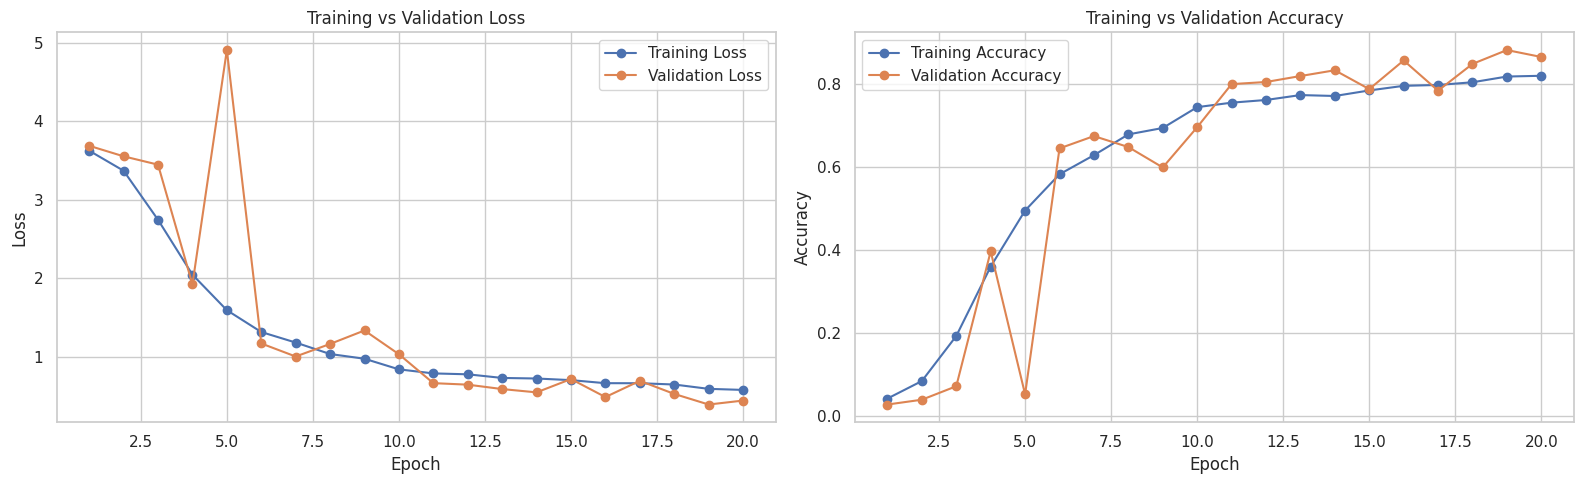

In [17]:
history_df = pd.DataFrame(baseline_history.history)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(history_df.index + 1, history_df["loss"], marker="o", label="Training Loss")
axes[0].plot(history_df.index + 1, history_df["val_loss"], marker="o", label="Validation Loss")
axes[0].set_title("Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(history_df.index + 1, history_df["accuracy"], marker="o", label="Training Accuracy")
axes[1].plot(history_df.index + 1, history_df["val_accuracy"], marker="o", label="Validation Accuracy")
axes[1].set_title("Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [18]:
val_probabilities = baseline_model.predict(val_generator, verbose=1)
y_pred = np.argmax(val_probabilities, axis=1)
y_true = val_generator.classes

accuracy = accuracy_score(y_true, y_pred)
macro_precision = precision_score(y_true, y_pred, average="macro", zero_division=0)
macro_recall = recall_score(y_true, y_pred, average="macro", zero_division=0)
macro_f1 = f1_score(y_true, y_pred, average="macro", zero_division=0)

weighted_precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

metrics_df = pd.DataFrame(
    {
        "Metric": [
            "Accuracy",
            "Macro Precision",
            "Macro Recall",
            "Macro F1-score",
            "Weighted Precision",
            "Weighted Recall",
            "Weighted F1-score",
        ],
        "Value": [
            accuracy,
            macro_precision,
            macro_recall,
            macro_f1,
            weighted_precision,
            weighted_recall,
            weighted_f1,
        ],
    }
)

display(metrics_df)

report = classification_report(
    y_true,
    y_pred,
    target_names=ordered_classes,
    zero_division=0,
    output_dict=True,
)
report_df = pd.DataFrame(report).transpose()
display(report_df)

68/68 ━━━━━━━━━━━━━━━━━━━━ 9s 120ms/step


,Metric,Value
0,Accuracy,0.881427
1,Macro Precision,0.882846
2,Macro Recall,0.881284
3,Macro F1-score,0.881037
4,Weighted Precision,0.883104
5,Weighted Recall,0.881427
6,Weighted F1-score,0.881246


,precision,recall,f1-score,support
0,0.892857,0.877193,0.884956,57.000000
1,0.894737,0.894737,0.894737,57.000000
2,0.932203,0.948276,0.940171,58.000000
3,0.918367,0.803571,0.857143,56.000000
4,0.792453,0.875000,0.831683,48.000000
5,0.887097,0.964912,0.924370,57.000000
6,0.894737,0.894737,0.894737,57.000000
7,0.946429,0.946429,0.946429,56.000000
8,0.962264,0.879310,0.918919,58.000000
9,0.915254,0.947368,0.931034,57.000000


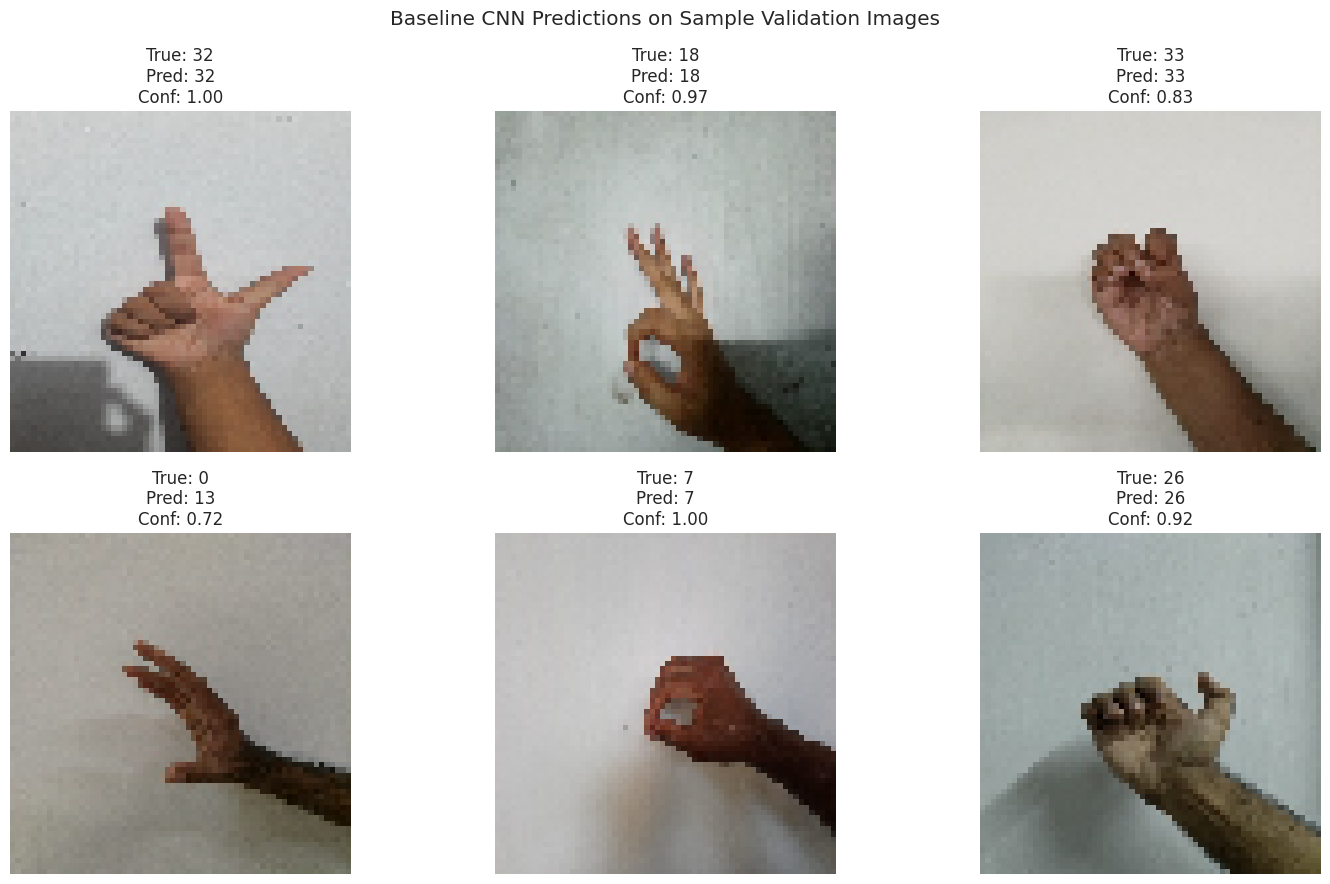

,filepath,label,pred_label,confidence
0,/content/drive/MyDrive/AI-ML/Sign Language Det...,32,32,0.999584
1,/content/drive/MyDrive/AI-ML/Sign Language Det...,18,18,0.970919
2,/content/drive/MyDrive/AI-ML/Sign Language Det...,33,33,0.830149
3,/content/drive/MyDrive/AI-ML/Sign Language Det...,0,13,0.724362
4,/content/drive/MyDrive/AI-ML/Sign Language Det...,7,7,0.995390
5,/content/drive/MyDrive/AI-ML/Sign Language Det...,26,26,0.922397


In [19]:
sample_predictions = val_df.sample(6, random_state=SEED).copy().reset_index(drop=True)

images = []
for file_path in sample_predictions["filepath"]:
    img = load_img(file_path, target_size=target_size)
    arr = img_to_array(img) / 255.0
    images.append(arr)

image_batch = np.stack(images)
sample_probabilities = baseline_model.predict(image_batch, verbose=0)
sample_predictions["pred_index"] = np.argmax(sample_probabilities, axis=1)
sample_predictions["pred_label"] = sample_predictions["pred_index"].map(lambda idx: ordered_classes[idx])
sample_predictions["confidence"] = np.max(sample_probabilities, axis=1)

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for ax, (_, row) in zip(axes, sample_predictions.iterrows()):
    img = load_img(row["filepath"], target_size=target_size)
    ax.imshow(img)
    ax.set_title(
        f"True: {row['label']}\nPred: {row['pred_label']}\nConf: {row['confidence']:.2f}"
    )
    ax.axis("off")

plt.suptitle("Baseline CNN Predictions on Sample Validation Images")
plt.tight_layout()
plt.show()

display(sample_predictions[["filepath", "label", "pred_label", "confidence"]])

In [20]:
import os
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Input,
    Conv2D,
    MaxPooling2D,
    GlobalAveragePooling2D,
    Dense,
    BatchNormalization,
    Dropout,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam, SGD

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow version:", tf.__version__)
print("Available GPUs:", gpus)

if not gpus:
    print("GPU not detected. ")

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [21]:
train_dir = "/content/drive/MyDrive/AI-ML/Sign Language Detection/Train"

class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))],
    key=int,
)

records = []
invalid_files = []
size_counter = Counter()

for class_name in class_names:
    class_dir = os.path.join(train_dir, class_name)
    for file_name in sorted(os.listdir(class_dir)):
        file_path = os.path.join(class_dir, file_name)
        if not os.path.isfile(file_path):
            continue

        try:
            with Image.open(file_path) as img:
                img.verify()
            with Image.open(file_path) as img:
                width, height = img.size
                channels = len(img.getbands())

            records.append(
                {
                    "filepath": file_path,
                    "label": class_name,
                    "width": width,
                    "height": height,
                    "channels": channels,
                }
            )
            size_counter[(width, height)] += 1
        except Exception as exc:
            invalid_files.append(
                {
                    "filepath": file_path,
                    "label": class_name,
                    "error_type": type(exc).__name__,
                }
            )

sign_df = pd.DataFrame(records)
invalid_df = pd.DataFrame(invalid_files)

ordered_classes = [str(label) for label in sorted(sign_df["label"].astype(int).unique())]
num_classes = len(ordered_classes)
target_size = (64, 64)
batch_size = 32

print("Valid images         :", len(sign_df))
print("Invalid images       :", len(invalid_df))
print("Number of classes    :", num_classes)
print("Most common size     :", size_counter.most_common(3))

Valid images         : 10792
Invalid images       : 266
Number of classes    : 38
Most common size     : [((224, 224), 10792)]


In [22]:
train_df, val_df = train_test_split(
    sign_df,
    test_size=0.20,
    stratify=sign_df["label"],
    random_state=SEED,
)


train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=(0.9, 1.1),
    fill_mode="nearest",
)
val_datagen = ImageDataGenerator(rescale=1.0 / 255)

def make_generators():
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="filepath",
        y_col="label",
        classes=ordered_classes,
        target_size=target_size,
        class_mode="categorical",
        batch_size=batch_size,
        shuffle=True,
        seed=SEED,
    )
    val_generator = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="filepath",
        y_col="label",
        classes=ordered_classes,
        target_size=target_size,
        class_mode="categorical",
        batch_size=batch_size,
        shuffle=False,
    )
    return train_generator, val_generator

train_generator, val_generator = make_generators()
input_shape = train_generator.image_shape

print("Input shape:", input_shape)
print("Train samples:", train_generator.n)
print("Validation samples:", val_generator.n)

Found 8633 validated image filenames belonging to 38 classes.
Found 2159 validated image filenames belonging to 38 classes.
Input shape: (64, 64, 3)
Train samples: 8633
Validation samples: 2159


In [23]:
from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adam

def build_baseline_cnn(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),

        # Block 1
        Conv2D(32, (3, 3), activation="relu", padding="same"),
        MaxPooling2D(pool_size=(2, 2)),

        # Block 2
        Conv2D(64, (3, 3), activation="relu", padding="same"),
        MaxPooling2D(pool_size=(2, 2)),

        # Block 3
        Conv2D(128, (3, 3), activation="relu", padding="same"),
        MaxPooling2D(pool_size=(2, 2)),

        GlobalAveragePooling2D(),

        Dense(256, activation="relu"),
        Dropout(0.5),          # only one dropout
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(num_classes, activation="softmax"),
    ])
    return model


def build_deeper_cnn(input_shape, num_classes, use_batch_norm=True, use_dropout=True):
    layers = [Input(shape=input_shape)]

    for filters in [32, 32]:
        layers.append(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        if use_batch_norm:
            layers.append(BatchNormalization())
    layers.append(MaxPooling2D(pool_size=(2, 2)))
    if use_dropout:
        layers.append(Dropout(0.25))

    for filters in [64, 64]:
        layers.append(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        if use_batch_norm:
            layers.append(BatchNormalization())
    layers.append(MaxPooling2D(pool_size=(2, 2)))
    if use_dropout:
        layers.append(Dropout(0.30))

    for filters in [128, 128]:
        layers.append(Conv2D(filters, (3, 3), padding="same", activation="relu"))
        if use_batch_norm:
            layers.append(BatchNormalization())
    layers.append(MaxPooling2D(pool_size=(2, 2)))
    if use_dropout:
        layers.append(Dropout(0.35))

    layers.extend([
        GlobalAveragePooling2D(),
        Dense(256, activation="relu"),
    ])
    if use_dropout:
        layers.append(Dropout(0.40))
    layers.extend([
        Dense(128, activation="relu"),
        Dense(64, activation="relu"),
        Dense(num_classes, activation="softmax"),
    ])

    return Sequential(layers)


def get_callbacks():
    return [
        EarlyStopping(
            monitor="val_loss",
            patience=4,
            restore_best_weights=True,
            verbose=1,
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            verbose=1,
        ),
    ]


def train_model(model, optimizer, train_generator, val_generator, epochs, label):
    model.compile(
        optimizer=optimizer,
        loss="categorical_crossentropy",
        metrics=["accuracy"],
    )

    start_time = time.perf_counter()
    history = model.fit(
        train_generator,
        validation_data=val_generator,
        epochs=epochs,
        callbacks=get_callbacks(),
        verbose=1,
    )
    elapsed = time.perf_counter() - start_time
    print(f"{label} training time: {elapsed:.2f} seconds")
    return history, elapsed


def evaluate_model(model, generator, label):
    probabilities = model.predict(generator, verbose=1)
    y_pred = np.argmax(probabilities, axis=1)
    y_true = generator.classes

    results = {
        "model": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "final_val_loss": float(model.evaluate(generator, verbose=0)[0]),
    }

    report = classification_report(
        y_true,
        y_pred,
        target_names=ordered_classes,
        zero_division=0,
        output_dict=True,
    )

    return results, pd.DataFrame(report).transpose()


def history_to_frame(history, model_name):
    history_df = pd.DataFrame(history.history)
    history_df["epoch"] = np.arange(1, len(history_df) + 1)
    history_df["model"] = model_name
    return history_df

# Step 3 - Deeper CNN with Regularization


In [24]:


deeper_adam_model = build_deeper_cnn(
    input_shape=input_shape,
    num_classes=num_classes,
    use_batch_norm=True,
    use_dropout=True,
)

deeper_adam_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 365,446 (1.39 MB)

 Trainable params: 364,550 (1.39 MB)

 Non-trainable params: 896 (3.50 KB)

In [25]:
# ── Step 1: Load data as numpy arrays ──
def load_data_as_arrays(df, target_size=(64, 64)):
    X, y = [], []
    for _, row in df.iterrows():
        img = load_img(row["filepath"], target_size=target_size)
        img = img_to_array(img) / 255.0
        X.append(img)
        y.append(int(row["label"]))
    X = np.array(X)
    y = tf.keras.utils.to_categorical(y, num_classes=num_classes)
    return X, y

print("Loading training data... (2-3 mins)")
X_train, y_train = load_data_as_arrays(train_df)
print("Loading validation data...")
X_val, y_val = load_data_as_arrays(val_df)
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

# ── Step 2: Train baseline model ──
tf.keras.backend.clear_session()

baseline_model = build_baseline_cnn(
    input_shape=(64, 64, 3),
    num_classes=num_classes
)

baseline_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

start_time = time.perf_counter()
baseline_history = baseline_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=get_callbacks(),
    verbose=1,
)
baseline_training_time = time.perf_counter() - start_time
print(f"Training time: {baseline_training_time:.2f} seconds")

Loading training data... (2-3 mins)
Loading validation data...
X_train shape: (8633, 64, 64, 3)
y_train shape: (8633, 38)
Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 9s 20ms/step - accuracy: 0.0213 - loss: 3.6388 - val_accuracy: 0.0269 - val_loss: 3.6374 - learning_rate: 0.0010
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.0227 - loss: 3.6381 - val_accuracy: 0.0269 - val_loss: 3.6373 - learning_rate: 0.0010
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.0242 - loss: 3.6379 - val_accuracy: 0.0269 - val_loss: 3.6372 - learning_rate: 0.0010
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.0239 - loss: 3.6373
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0234 - loss: 3.6379 - val_accuracy: 0.0269 - val_loss: 3.6374 - learning_rate: 0.0010
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.0254 - loss: 3.6380 - val_accuracy: 0.0269 - val_los

In [26]:
# ── Build deeper CNN ──
deeper_adam_model = build_deeper_cnn(
    input_shape=(64, 64, 3),
    num_classes=num_classes,
    use_batch_norm=True,
    use_dropout=True,
)

deeper_adam_model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

deeper_adam_model.summary()

# ── Train ──
start_time = time.perf_counter()

deeper_adam_history = deeper_adam_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=get_callbacks(),
    verbose=1,
)

deeper_adam_training_time = time.perf_counter() - start_time
print(f"Training time: {deeper_adam_training_time:.2f} seconds")

# ── Evaluate ──
y_pred = np.argmax(deeper_adam_model.predict(X_val, verbose=0), axis=1)
y_true = np.argmax(y_val, axis=1)

deeper_adam_results = {
    "model": "Deeper CNN (Adam)",
    "accuracy": accuracy_score(y_true, y_pred),
    "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
    "training_time_seconds": deeper_adam_training_time,
}

display(pd.DataFrame([deeper_adam_results]))

# ── Save ──
deeper_adam_model.save("/content/drive/MyDrive/AI-ML/deeper_adam_model.keras")
print("Deeper model saved!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 365,446 (1.39 MB)

 Trainable params: 364,550 (1.39 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 27s 53ms/step - accuracy: 0.0485 - loss: 3.5965 - val_accuracy: 0.0283 - val_loss: 3.8010 - learning_rate: 0.0010
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.1718 - loss: 2.8187 - val_accuracy: 0.2422 - val_loss: 2.5312 - learning_rate: 0.0010
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4179 - loss: 1.8173 - val_accuracy: 0.4919 - val_loss: 1.6389 - learning_rate: 0.0010
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.5921 - loss: 1.2923 - val_accuracy: 0.5563 - val_loss: 1.4090 - learning_rate: 0.0010
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6811 - loss: 1.0293 - val_accuracy: 0.7689 - val_loss: 0.7850 - learning_rate: 0.0010
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.7219 - loss: 0.8771 - val_accuracy: 0.7814 - val_loss: 0.7357 - learning_rate: 0.0010
Epoch 7/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.7622 - loss: 0

,model,accuracy,macro_f1,weighted_f1,training_time_seconds
0,Deeper CNN (Adam),0.891153,0.890656,0.891244,107.534326


Deeper model saved!


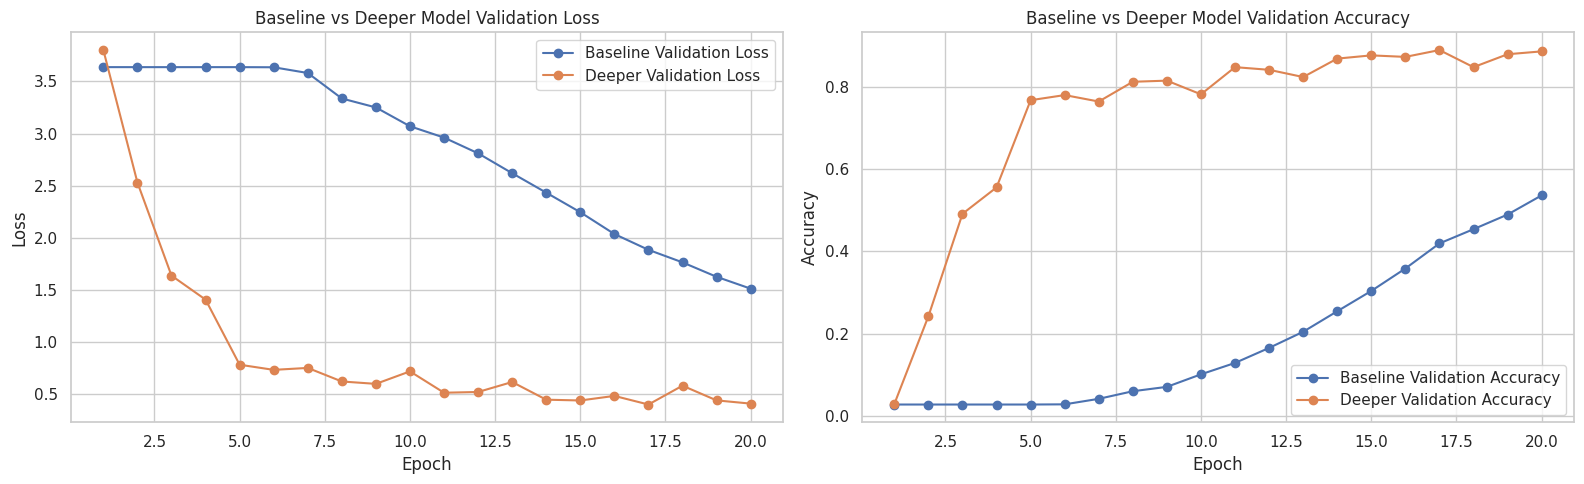

In [27]:
baseline_history_df = history_to_frame(baseline_history, "Baseline CNN (Adam)")
deeper_adam_history_df = history_to_frame(deeper_adam_history, "Deeper CNN + BN + Dropout (Adam)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(
    baseline_history_df["epoch"],
    baseline_history_df["val_loss"],
    marker="o",
    label="Baseline Validation Loss",
)
axes[0].plot(
    deeper_adam_history_df["epoch"],
    deeper_adam_history_df["val_loss"],
    marker="o",
    label="Deeper Validation Loss",
)
axes[0].set_title("Baseline vs Deeper Model Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    baseline_history_df["epoch"],
    baseline_history_df["val_accuracy"],
    marker="o",
    label="Baseline Validation Accuracy",
)
axes[1].plot(
    deeper_adam_history_df["epoch"],
    deeper_adam_history_df["val_accuracy"],
    marker="o",
    label="Deeper Validation Accuracy",
)
axes[1].set_title("Baseline vs Deeper Model Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [28]:
# ── Evaluate baseline ──
y_pred_base = np.argmax(baseline_model.predict(X_val, verbose=0), axis=1)
y_true = np.argmax(y_val, axis=1)

baseline_results = {
    "model": "Baseline CNN (Adam)",
    "accuracy": accuracy_score(y_true, y_pred_base),
    "macro_precision": precision_score(y_true, y_pred_base, average="macro", zero_division=0),
    "macro_recall": recall_score(y_true, y_pred_base, average="macro", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred_base, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred_base, average="weighted", zero_division=0),
    "training_time_seconds": baseline_training_time,
}

# ── Evaluate deeper ──
y_pred_deeper = np.argmax(deeper_adam_model.predict(X_val, verbose=0), axis=1)

deeper_adam_results = {
    "model": "Deeper CNN (Adam)",
    "accuracy": accuracy_score(y_true, y_pred_deeper),
    "macro_precision": precision_score(y_true, y_pred_deeper, average="macro", zero_division=0),
    "macro_recall": recall_score(y_true, y_pred_deeper, average="macro", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred_deeper, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred_deeper, average="weighted", zero_division=0),
    "training_time_seconds": deeper_adam_training_time,
}

# ── Compare both ──
comparison_df = pd.DataFrame([baseline_results, deeper_adam_results])
display(comparison_df)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_seconds
0,Baseline CNN (Adam),0.536823,0.543866,0.535541,0.525237,0.526636,50.062365
1,Deeper CNN (Adam),0.891153,0.894793,0.890635,0.890656,0.891244,107.534326


# Step 4 - Experimentation and Comparative Analysis


In [29]:
# ── Build deeper CNN with SGD ──
deeper_sgd_model = build_deeper_cnn(
    input_shape=(64, 64, 3),
    num_classes=num_classes,
    use_batch_norm=True,
    use_dropout=True,
)

deeper_sgd_model.compile(
    optimizer=SGD(learning_rate=1e-2, momentum=0.9, nesterov=True),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

deeper_sgd_model.summary()

# ── Train ──
start_time = time.perf_counter()

deeper_sgd_history = deeper_sgd_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=32,
    callbacks=get_callbacks(),
    verbose=1,
)

deeper_sgd_training_time = time.perf_counter() - start_time
print(f"Training time: {deeper_sgd_training_time:.2f} seconds")

# ── Evaluate ──
y_pred_sgd = np.argmax(deeper_sgd_model.predict(X_val, verbose=0), axis=1)
y_true = np.argmax(y_val, axis=1)

deeper_sgd_results = {
    "model": "Deeper CNN (SGD)",
    "accuracy": accuracy_score(y_true, y_pred_sgd),
    "macro_precision": precision_score(y_true, y_pred_sgd, average="macro", zero_division=0),
    "macro_recall": recall_score(y_true, y_pred_sgd, average="macro", zero_division=0),
    "macro_f1": f1_score(y_true, y_pred_sgd, average="macro", zero_division=0),
    "weighted_f1": f1_score(y_true, y_pred_sgd, average="weighted", zero_division=0),
    "training_time_seconds": deeper_sgd_training_time,
}

display(pd.DataFrame([deeper_sgd_results]))

# ── Save ──
deeper_sgd_model.save("/content/drive/MyDrive/AI-ML/deeper_sgd_model.keras")
print("SGD model saved!")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 64, 64, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 16, 16, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 365,446 (1.39 MB)

 Trainable params: 364,550 (1.39 MB)

 Non-trainable params: 896 (3.50 KB)

Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 21s 47ms/step - accuracy: 0.0400 - loss: 3.6352 - val_accuracy: 0.0259 - val_loss: 3.6853 - learning_rate: 0.0100
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.0824 - loss: 3.4248 - val_accuracy: 0.1130 - val_loss: 3.1599 - learning_rate: 0.0100
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.1593 - loss: 2.8155 - val_accuracy: 0.0621 - val_loss: 3.8292 - learning_rate: 0.0100
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.2515 - loss: 2.3660
Epoch 4: ReduceLROnPlateau reducing learning rate to 0.004999999888241291.
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.2926 - loss: 2.2046 - val_accuracy: 0.0903 - val_loss: 4.0576 - learning_rate: 0.0100
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 15ms/step - accuracy: 0.4608 - loss: 1.6608 - val_accuracy: 0.1871 - val_loss: 2.8449 - learning_rate: 0.0050
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 4s 16ms/step - accuracy: 0.5287 - loss: 1.4

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,training_time_seconds
0,Deeper CNN (SGD),0.872626,0.881988,0.87261,0.871743,0.872091,100.025966


SGD model saved!


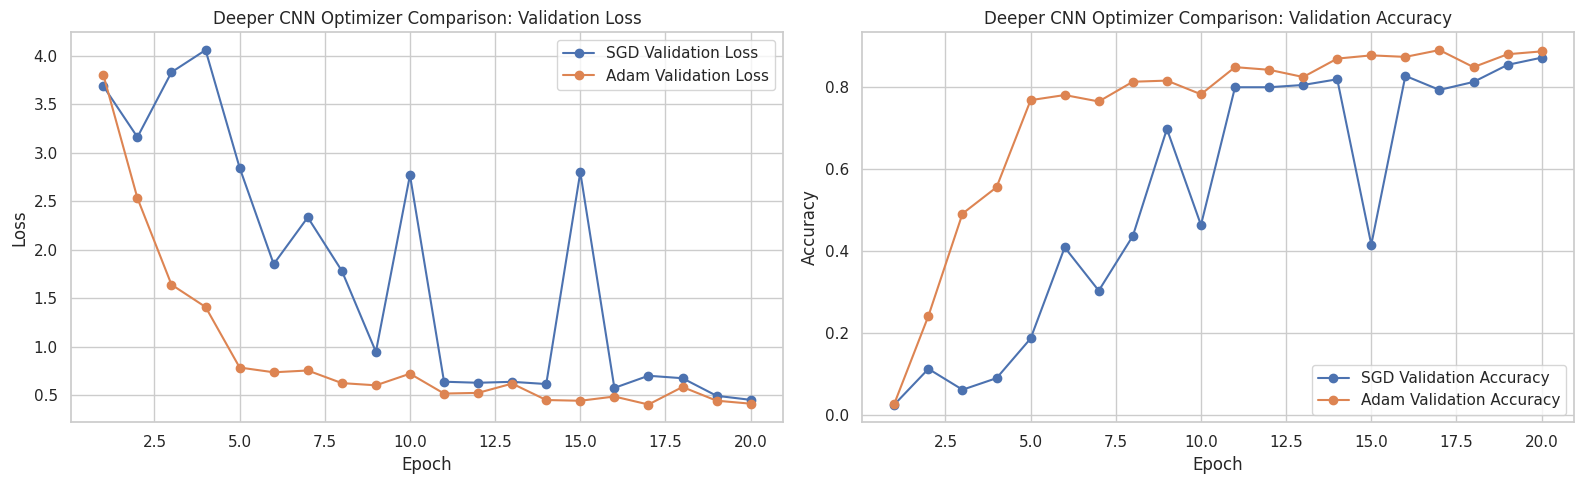

In [30]:
deeper_sgd_history_df = history_to_frame(deeper_sgd_history, "Deeper CNN + BN + Dropout (SGD)")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(
    deeper_sgd_history_df["epoch"],
    deeper_sgd_history_df["val_loss"],
    marker="o",
    label="SGD Validation Loss",
)
axes[0].plot(
    deeper_adam_history_df["epoch"],
    deeper_adam_history_df["val_loss"],
    marker="o",
    label="Adam Validation Loss",
)
axes[0].set_title("Deeper CNN Optimizer Comparison: Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    deeper_sgd_history_df["epoch"],
    deeper_sgd_history_df["val_accuracy"],
    marker="o",
    label="SGD Validation Accuracy",
)
axes[1].plot(
    deeper_adam_history_df["epoch"],
    deeper_adam_history_df["val_accuracy"],
    marker="o",
    label="Adam Validation Accuracy",
)
axes[1].set_title("Deeper CNN Optimizer Comparison: Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [31]:
deeper_no_dropout_model = build_deeper_cnn(
    input_shape=input_shape,
    num_classes=num_classes,
    use_batch_norm=True,
    use_dropout=False,
)

train_generator, val_generator = make_generators()
deeper_no_dropout_history, deeper_no_dropout_training_time = train_model(
    deeper_no_dropout_model,
    Adam(learning_rate=1e-3),
    train_generator,
    val_generator,
    epochs=20,
    label="Deeper CNN + BN only (Adam)",
)

deeper_no_dropout_results, deeper_no_dropout_report = evaluate_model(
    deeper_no_dropout_model,
    val_generator,
    label="Deeper CNN + BN only (Adam)",
)
display(pd.DataFrame([deeper_no_dropout_results]))

Found 8633 validated image filenames belonging to 38 classes.
Found 2159 validated image filenames belonging to 38 classes.
Epoch 1/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 64s 205ms/step - accuracy: 0.0768 - loss: 3.4276 - val_accuracy: 0.0301 - val_loss: 4.1149 - learning_rate: 0.0010
Epoch 2/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 73s 188ms/step - accuracy: 0.3414 - loss: 2.1537 - val_accuracy: 0.3298 - val_loss: 2.1210 - learning_rate: 0.0010
Epoch 3/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 54s 201ms/step - accuracy: 0.6096 - loss: 1.2347 - val_accuracy: 0.5683 - val_loss: 1.3772 - learning_rate: 0.0010
Epoch 4/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 56s 207ms/step - accuracy: 0.7262 - loss: 0.8985 - val_accuracy: 0.7531 - val_loss: 0.8269 - learning_rate: 0.0010
Epoch 5/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 51s 190ms/step - accuracy: 0.7762 - loss: 0.7297 - val_accuracy: 0.7869 - val_loss: 0.7458 - learning_rate: 0.0010
Epoch 6/20
270/270 ━━━━━━━━━━━━━━━━━━━━ 51s 190ms/step - accuracy: 0.8119 - loss: 0.6269 - val_accura

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,final_val_loss
0,Deeper CNN + BN only (Adam),0.922186,0.924624,0.922047,0.922228,0.924673,0.922186,0.922316,0.282667


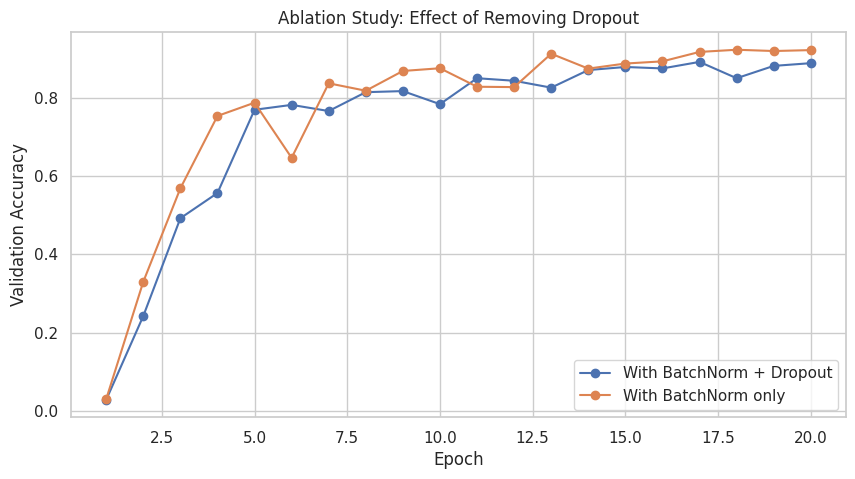

In [32]:
deeper_no_dropout_history_df = history_to_frame(deeper_no_dropout_history, "Deeper CNN + BN only (Adam)")

plt.figure(figsize=(10, 5))
plt.plot(
    deeper_adam_history_df["epoch"],
    deeper_adam_history_df["val_accuracy"],
    marker="o",
    label="With BatchNorm + Dropout",
)
plt.plot(
    deeper_no_dropout_history_df["epoch"],
    deeper_no_dropout_history_df["val_accuracy"],
    marker="o",
    label="With BatchNorm only",
)
plt.title("Ablation Study: Effect of Removing Dropout")
plt.xlabel("Epoch")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

In [33]:
deeper_sgd_results["training_time_seconds"] = deeper_sgd_training_time
deeper_no_dropout_results["training_time_seconds"] = deeper_no_dropout_training_time

comparison_df = pd.DataFrame(
    [
        baseline_results,
        deeper_adam_results,
        deeper_sgd_results,
        deeper_no_dropout_results,
    ]
)

comparison_df = comparison_df[
    [
        "model",
        "accuracy",
        "macro_precision",
        "macro_recall",
        "macro_f1",
        "weighted_f1",
        "final_val_loss",
        "training_time_seconds",
    ]
].sort_values("macro_f1", ascending=False)

display(comparison_df)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_f1,final_val_loss,training_time_seconds
3,Deeper CNN + BN only (Adam),0.922186,0.924624,0.922047,0.922228,0.922316,0.282667,1075.720086
1,Deeper CNN (Adam),0.891153,0.894793,0.890635,0.890656,0.891244,NaN,107.534326
2,Deeper CNN (SGD),0.872626,0.881988,0.872610,0.871743,0.872091,NaN,100.025966
0,Baseline CNN (Adam),0.536823,0.543866,0.535541,0.525237,0.526636,NaN,50.062365


In [34]:
hardware_used = "GPU" if gpus else "CPU"
total_training_time = (
    baseline_training_time
    + deeper_adam_training_time
    + deeper_sgd_training_time
    + deeper_no_dropout_training_time
)

run_summary = pd.DataFrame(
    {
        "item": [
            "Hardware used",
            "Baseline training time (s)",
            "Deeper Adam training time (s)",
            "Deeper SGD training time (s)",
            "Ablation training time (s)",
            "Total experiment time (s)",
        ],
        "value": [
            hardware_used,
            baseline_training_time,
            deeper_adam_training_time,
            deeper_sgd_training_time,
            deeper_no_dropout_training_time,
            total_training_time,
        ],
    }
)

display(run_summary)

,item,value
0,Hardware used,GPU
1,Baseline training time (s),50.062365
2,Deeper Adam training time (s),107.534326
3,Deeper SGD training time (s),100.025966
4,Ablation training time (s),1075.720086
5,Total experiment time (s),1333.342743


# Part B - Transfer Learning


In [35]:
import os
import time
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow.keras import Sequential, Model
from tensorflow.keras.layers import (
    Input,
    Dense,
    Dropout,
    BatchNormalization,
    GlobalAveragePooling2D,
)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

gpus = tf.config.list_physical_devices("GPU")
print("TensorFlow version:", tf.__version__)
print("Available GPUs:", gpus)

if not gpus:
    print("GPU not detected. In Colab, enable GPU from Runtime -> Change runtime type -> GPU.")

TensorFlow version: 2.20.0
Available GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Step 1 - Reinspect the Dataset for Transfer Learning Decisions


In [39]:



train_dir = "/content/drive/MyDrive/AI-ML/Sign Language Detection/Train"


class_names = sorted(
    [d for d in os.listdir(train_dir) if os.path.isdir(os.path.join(train_dir, d))],
    key=int,
)

records = []
invalid_files = []
size_counter = Counter()
channel_counter = Counter()

for class_name in class_names:
    class_dir = os.path.join(train_dir, class_name)
    for file_name in sorted(os.listdir(class_dir)):
        file_path = os.path.join(class_dir, file_name)
        if not os.path.isfile(file_path):
            continue

        try:
            with Image.open(file_path) as img:
                img.verify()
            with Image.open(file_path) as img:
                width, height = img.size
                channels = len(img.getbands())

            records.append(
                {
                    "filepath": file_path,
                    "label": class_name,
                    "width": width,
                    "height": height,
                    "channels": channels,
                }
            )
            size_counter[(width, height)] += 1
            channel_counter[channels] += 1
        except Exception as exc:
            invalid_files.append(
                {
                    "filepath": file_path,
                    "label": class_name,
                    "error_type": type(exc).__name__,
                }
            )

sign_df = pd.DataFrame(records)
invalid_df = pd.DataFrame(invalid_files)

ordered_classes = [str(label) for label in sorted(sign_df["label"].astype(int).unique())]
num_classes = len(ordered_classes)

print("Valid images         :", len(sign_df))
print("Invalid images       :", len(invalid_df))
print("Number of classes    :", num_classes)
print("Image sizes found    :", size_counter.most_common(5))
print("Channel counts       :", dict(channel_counter))

class_distribution = (
    sign_df["label"]
    .value_counts()
    .rename_axis("label")
    .reset_index(name="count")
)
class_distribution["label"] = class_distribution["label"].astype(int)
class_distribution = class_distribution.sort_values("label").reset_index(drop=True)

display(class_distribution.head(10))

Valid images         : 10792
Invalid images       : 266
Number of classes    : 38
Image sizes found    : [((224, 224), 10792)]
Channel counts       : {3: 10792}


,label,count
0,0,286
1,1,287
2,2,291
3,3,279
4,4,239
5,5,287
6,6,284
7,7,282
8,8,290
9,9,285


## Step 2 - Train / Validation Split and Generators


In [41]:
train_df, val_df = train_test_split(
    sign_df,
    test_size=0.20,
    stratify=sign_df["label"],
    random_state=SEED,
)

input_height = 224
input_width = 224
target_size = (input_height, input_width)
batch_size = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=12,
    width_shift_range=0.10,
    height_shift_range=0.10,
    zoom_range=0.10,
    brightness_range=(0.9, 1.1),
    fill_mode="nearest",
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

def make_generators():
    train_generator = train_datagen.flow_from_dataframe(
        dataframe=train_df,
        x_col="filepath",
        y_col="label",
        classes=ordered_classes,
        target_size=target_size,
        class_mode="categorical",
        batch_size=batch_size,
        shuffle=True,
        seed=SEED,
    )

    val_generator = val_datagen.flow_from_dataframe(
        dataframe=val_df,
        x_col="filepath",
        y_col="label",
        classes=ordered_classes,
        target_size=target_size,
        class_mode="categorical",
        batch_size=batch_size,
        shuffle=False,
    )
    return train_generator, val_generator

train_generator, val_generator = make_generators()
input_shape = train_generator.image_shape

print("Input shape from generator:", input_shape)
print("Number of classes         :", len(train_generator.class_indices))
print("Training samples          :", train_generator.n)
print("Validation samples        :", val_generator.n)

Found 8633 validated image filenames belonging to 38 classes.
Found 2159 validated image filenames belonging to 38 classes.
Input shape from generator: (224, 224, 3)
Number of classes         : 38
Training samples          : 8633
Validation samples        : 2159


## Step 3 - Build the Transfer Learning Model


In [42]:
def build_transfer_model(input_shape, num_classes, base_trainable=False):
    base_model = MobileNetV2(
        input_shape=input_shape,
        include_top=False,
        weights="imagenet",
    )
    base_model.trainable = base_trainable

    inputs = Input(shape=input_shape)
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = BatchNormalization()(x)
    x = Dense(256, activation="relu")(x)
    x = Dropout(0.35)(x)
    outputs = Dense(num_classes, activation="softmax")(x)

    model = Model(inputs, outputs)
    return model, base_model

# Phase 1 - Feature Extraction


In [45]:
transfer_model_feature, base_model = build_transfer_model(
    input_shape=input_shape,
    num_classes=len(train_generator.class_indices),
    base_trainable=False,
)

transfer_model_feature.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

transfer_model_feature.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_4      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_18          │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_16 (Dense)                │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_17 (Dense)                │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,600,806 (9.92 MB)

 Trainable params: 340,262 (1.30 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [54]:
import json

input_height = 224
input_width  = 224
target_size  = (input_height, input_width)
train_generator, val_generator = make_generators()

transfer_model_feature = tf.keras.models.load_model("/content/drive/MyDrive/AI-ML/transfer_model_feature.keras")
print("Model loaded!")

with open("/content/drive/MyDrive/AI-ML/feature_history.json") as f:
    history_feature = json.load(f)

feature_extraction_time = 0
print("Done!")

Found 8633 validated image filenames belonging to 38 classes.
Found 2159 validated image filenames belonging to 38 classes.
Model loaded!
Done!


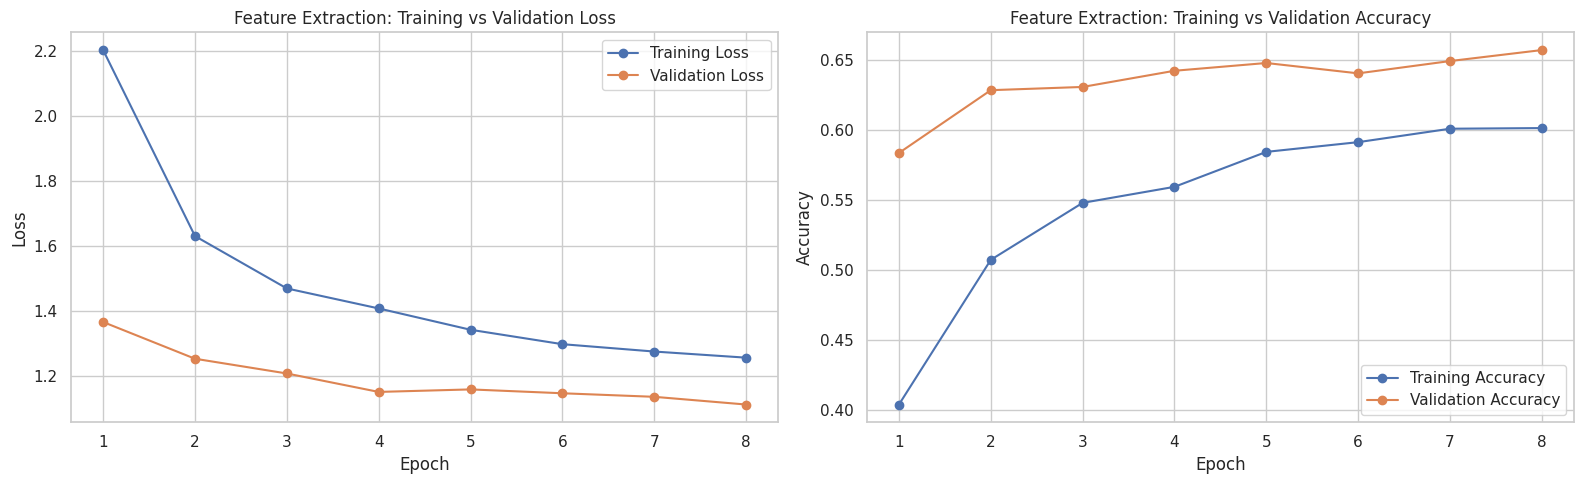

In [56]:
feature_history_df = pd.DataFrame(history_feature)
feature_history_df["epoch"] = np.arange(1, len(feature_history_df) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(feature_history_df["epoch"], feature_history_df["loss"], marker="o", label="Training Loss")
axes[0].plot(feature_history_df["epoch"], feature_history_df["val_loss"], marker="o", label="Validation Loss")
axes[0].set_title("Feature Extraction: Training vs Validation Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(feature_history_df["epoch"], feature_history_df["accuracy"], marker="o", label="Training Accuracy")
axes[1].plot(feature_history_df["epoch"], feature_history_df["val_accuracy"], marker="o", label="Validation Accuracy")
axes[1].set_title("Feature Extraction: Training vs Validation Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [57]:
def evaluate_model(model, generator, label):
    probabilities = model.predict(generator, verbose=1)
    y_pred = np.argmax(probabilities, axis=1)
    y_true = generator.classes

    results = {
        "model": label,
        "accuracy": accuracy_score(y_true, y_pred),
        "macro_precision": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_recall": recall_score(y_true, y_pred, average="macro", zero_division=0),
        "macro_f1": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "weighted_precision": precision_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_recall": recall_score(y_true, y_pred, average="weighted", zero_division=0),
        "weighted_f1": f1_score(y_true, y_pred, average="weighted", zero_division=0),
        "val_loss": float(model.evaluate(generator, verbose=0)[0]),
    }

    report = classification_report(
        y_true,
        y_pred,
        target_names=ordered_classes,
        zero_division=0,
        output_dict=True,
    )

    return results, pd.DataFrame(report).transpose()

feature_results, feature_report = evaluate_model(
    transfer_model_feature,
    val_generator,
    label="Transfer Learning - Feature Extraction",
)

feature_results["training_time_seconds"] = feature_extraction_time
display(pd.DataFrame([feature_results]))

68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 200ms/step


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,val_loss,training_time_seconds
0,Transfer Learning - Feature Extraction,0.230199,0.30236,0.229929,0.190601,0.301945,0.230199,0.19029,2.923453,0


# Phase 2 - Fine-Tuning


In [58]:
base_model.trainable = True

fine_tune_at = 100
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

transfer_model_feature.compile(
    optimizer=Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"],
)

fine_tune_epochs = 6
total_epochs = len(history_feature["loss"]) + fine_tune_epochs

train_generator, val_generator = make_generators()

start_time = time.perf_counter()
history_fine = transfer_model_feature.fit(
    train_generator,
    validation_data=val_generator,
    epochs=total_epochs,
    initial_epoch=len(history_feature["loss"]),
    callbacks=get_callbacks(),
    verbose=1,
)
fine_tuning_time = time.perf_counter() - start_time

print(f"Fine-tuning training time: {fine_tuning_time:.2f} seconds")

Found 8633 validated image filenames belonging to 38 classes.
Found 2159 validated image filenames belonging to 38 classes.
Epoch 9/14
270/270 ━━━━━━━━━━━━━━━━━━━━ 182s 638ms/step - accuracy: 0.4597 - loss: 1.8107 - val_accuracy: 0.5248 - val_loss: 1.5658 - learning_rate: 1.0000e-05
Epoch 10/14
270/270 ━━━━━━━━━━━━━━━━━━━━ 151s 559ms/step - accuracy: 0.4780 - loss: 1.7169 - val_accuracy: 0.5544 - val_loss: 1.4662 - learning_rate: 1.0000e-05
Epoch 11/14
270/270 ━━━━━━━━━━━━━━━━━━━━ 151s 559ms/step - accuracy: 0.5035 - loss: 1.6399 - val_accuracy: 0.5688 - val_loss: 1.4035 - learning_rate: 1.0000e-05
Epoch 12/14
270/270 ━━━━━━━━━━━━━━━━━━━━ 151s 561ms/step - accuracy: 0.5089 - loss: 1.5967 - val_accuracy: 0.5790 - val_loss: 1.3551 - learning_rate: 1.0000e-05
Epoch 13/14
270/270 ━━━━━━━━━━━━━━━━━━━━ 200s 554ms/step - accuracy: 0.5270 - loss: 1.5473 - val_accuracy: 0.5901 - val_loss: 1.3035 - learning_rate: 1.0000e-05
Epoch 14/14
270/270 ━━━━━━━━━━━━━━━━━━━━ 149s 553ms/step - accuracy: 0.5

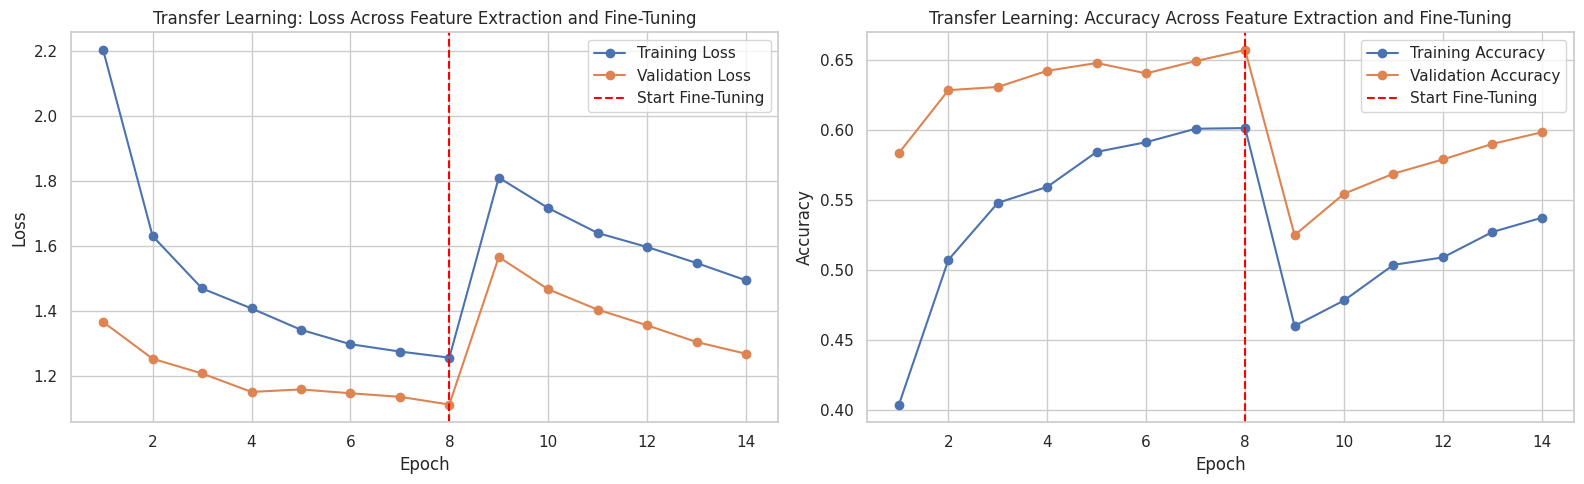

In [59]:
combined_history = {}
for key in history_feature.keys():
    combined_history[key] = history_feature[key] + history_fine.history[key]

fine_history_df = pd.DataFrame(combined_history)
fine_history_df["epoch"] = np.arange(1, len(fine_history_df) + 1)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].plot(
    fine_history_df["epoch"],
    fine_history_df["loss"],
    marker="o",
    label="Training Loss",
)
axes[0].plot(
    fine_history_df["epoch"],
    fine_history_df["val_loss"],
    marker="o",
    label="Validation Loss",
)
axes[0].axvline(
    x=len(history_feature["loss"]),
    color="red",
    linestyle="--",
    label="Start Fine-Tuning",
)
axes[0].set_title("Transfer Learning: Loss Across Feature Extraction and Fine-Tuning")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(
    fine_history_df["epoch"],
    fine_history_df["accuracy"],
    marker="o",
    label="Training Accuracy",
)
axes[1].plot(
    fine_history_df["epoch"],
    fine_history_df["val_accuracy"],
    marker="o",
    label="Validation Accuracy",
)
axes[1].axvline(
    x=len(history_feature["loss"]),
    color="red",
    linestyle="--",
    label="Start Fine-Tuning",
)
axes[1].set_title("Transfer Learning: Accuracy Across Feature Extraction and Fine-Tuning")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

In [60]:
fine_tuned_results, fine_tuned_report = evaluate_model(
    transfer_model_feature,
    val_generator,
    label="Transfer Learning - Fine-Tuned",
)

fine_tuned_results["training_time_seconds"] = feature_extraction_time + fine_tuning_time
display(pd.DataFrame([fine_tuned_results]))

68/68 ━━━━━━━━━━━━━━━━━━━━ 19s 204ms/step


,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,val_loss,training_time_seconds
0,Transfer Learning - Fine-Tuned,0.598425,0.609106,0.598558,0.594234,0.608552,0.598425,0.593895,1.26732,988.346455


In [61]:
transfer_comparison_df = pd.DataFrame([feature_results, fine_tuned_results])
display(transfer_comparison_df)

,model,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1,val_loss,training_time_seconds
0,Transfer Learning - Feature Extraction,0.230199,0.302360,0.229929,0.190601,0.301945,0.230199,0.190290,2.923453,0.000000
1,Transfer Learning - Fine-Tuned,0.598425,0.609106,0.598558,0.594234,0.608552,0.598425,0.593895,1.267320,988.346455


In [62]:
scratch_results = pd.DataFrame(
    [
        {
            "model": "Baseline CNN from Scratch",
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "val_loss": np.nan,
            "training_time_seconds": np.nan,
        },
        {
            "model": "Deeper CNN from Scratch",
            "accuracy": np.nan,
            "macro_f1": np.nan,
            "val_loss": np.nan,
            "training_time_seconds": np.nan,
        },
    ]
)

transfer_summary = pd.DataFrame(
    [
        {
            "model": feature_results["model"],
            "accuracy": feature_results["accuracy"],
            "macro_f1": feature_results["macro_f1"],
            "val_loss": feature_results["val_loss"],
            "training_time_seconds": feature_results["training_time_seconds"],
        },
        {
            "model": fine_tuned_results["model"],
            "accuracy": fine_tuned_results["accuracy"],
            "macro_f1": fine_tuned_results["macro_f1"],
            "val_loss": fine_tuned_results["val_loss"],
            "training_time_seconds": fine_tuned_results["training_time_seconds"],
        },
    ]
)

final_comparison_df = pd.concat([scratch_results, transfer_summary], ignore_index=True)
display(final_comparison_df)

,model,accuracy,macro_f1,val_loss,training_time_seconds
0,Baseline CNN from Scratch,NaN,NaN,NaN,NaN
1,Deeper CNN from Scratch,NaN,NaN,NaN,NaN
2,Transfer Learning - Feature Extraction,0.230199,0.190601,2.923453,0.000000
3,Transfer Learning - Fine-Tuned,0.598425,0.594234,1.267320,988.346455


In [63]:
hardware_used = "GPU" if gpus else "CPU"
total_transfer_time = feature_extraction_time + fine_tuning_time

run_summary = pd.DataFrame(
    {
        "item": [
            "Chosen pre-trained model",
            "Hardware used",
            "Feature extraction time (s)",
            "Fine-tuning time (s)",
            "Total transfer learning time (s)",
            "Number of classes",
            "Input size used",
        ],
        "value": [
            "MobileNetV2",
            hardware_used,
            feature_extraction_time,
            fine_tuning_time,
            total_transfer_time,
            num_classes,
            f"{input_height} x {input_width}",
        ],
    }
)

display(run_summary)

,item,value
0,Chosen pre-trained model,MobileNetV2
1,Hardware used,GPU
2,Feature extraction time (s),0
3,Fine-tuning time (s),988.346455
4,Total transfer learning time (s),988.346455
5,Number of classes,38
6,Input size used,224 x 224
